<a href="https://colab.research.google.com/github/barry-clarke/CS5004/blob/main/Etivity3_24325082_Tasks1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1
Implement tabular Q-Learning for the problem outlined in Example 6.6 (Cliff Walking Grid World) in the Reinforcement Learning [Sutton and Barto’s text](https://incompleteideas.net/book/the-book-2nd.html) on Reinforcement Learning, 2nd Edition (2018)

My Understanding: the Cliff Walking example from Sutton and Barto is a classic grid world problem used to compare different Temporal Difference (TD) learning methods. In this  4 x 12 environment, an agent must find a path from a start state (S) to a goal (G). Every step taken gives a reward of -1, but falling into the "cliff" region results in a penalty of -100 and sends the agent back to the start.

The Layout: The world is a grid where the agent starts at the bottom-left and must reach the bottom-right
The Rewards: Every step gives a reward of -1. Falling into the cliff (the bottom row between start and goal) gives a reward of -100 and sends the agent back to the start
The Objective: Maximise the long-term reward by finding the shortest path to the goal

The example highlights the difference between On-policy and Off-policy learning:

> Q-Learning (Off-policy): This algorithm seeks to learn the optimal policy directly. Because it updates its values based on the maximum potential reward of the next state, it learns the absolute shortest path—which is the edge of the cliff. However, because the agent still uses an epsilon-greedy strategy to explore, it occasionally makes random moves, falls off the cliff, and suffers the -100 penalty, leading to a lower total reward during training.

Using the content [Q Learning vs SARSA](https://medium.com/@priya61197/q-learning-vs-sarsa-b9e433dec930) for the inspiration to use pseudocode, coupled with the Lesson 4 slides

#### Q-Learning Pseudocode (Off-Policy TD Control) REF: Lesson 4, Slide 14, TD: Q Learning

```text
Initialise:
    Initialise Q(s, a) for all states s and actions a arbitrarily
    Initialise Q(terminal, *) = 0

Repeat (for each episode):
    1. Initialise starting state S

    2. Repeat (for each step of the episode):

        a. Select an action A from state S using an epsilon-greedy policy derived from Q
           (Choose the action with highest Q(S,a) with probability 1−epsilon;
            otherwise choose a random action)

        b. Take action A, observe reward R and next state S'

        c. Update the Q-value for the state–action pair (S, A):
           Q(S, A) ← Q(S, A) + alpha * [R + gamma * max_a Q(S', a) − Q(S, A)]

        d. Update state:
           S ← S'

    Until S is a terminal state
```

> Sarsa (On-policy): Unlike Q-Learning, Sarsa learns based on the actual actions it takes, including its random exploration. It "realises" that its own tendency to explore makes the cliff edge dangerous. Consequently, it learns a safer path further away from the cliff, which results in a higher sum of rewards during the learning process

### Sarsa Pseudocode (On-Policy TD Control) REF: Lesson 4, Slide 9, TD Learning: Sarsa

```text
Initialise:
    Initialise Q(s, a) for all states s and actions a arbitrarily
    Initialise Q(terminal, *) = 0

Repeat (for each episode):
    1. Initialise starting state S

    2. Select an action A from state S using an epsilon-greedy policy derived from Q
       (Choose the action with highest Q(S,a) with probability 1−epsilon;
        otherwise choose a random action)

    3. Repeat (for each step of the episode):

        a. Take action A, observe reward R and next state S'

        b. Select an action A' from state S' using an epsilon-greedy policy derived from Q

        c. Update the Q-value for the state–action pair (S, A):
           Q(S, A) ← Q(S, A) + alpha * [R + gamma * Q(S', A') − Q(S, A)]

        d. Update state and action:
           S ← S'
           A ← A'

    Until S is a terminal state
```
###Q-Learning vs SARSA (Logical Differences Referencing Pseudocode)

| Aspect                             | **Q-Learning (Off-Policy)**                                          | **SARSA (On-Policy)**                                           |
| ---------------------------------- | -------------------------------------------------------------------- | --------------------------------------------------------------- |
| **Update Equation**                | `Q(S, A) ← Q(S, A) + alpha * [R + gamma * max_a Q(S', a) − Q(S, A)]` | `Q(S, A) ← Q(S, A) + alpha * [R + gamma * Q(S', A') − Q(S, A)]` |
| **Where seen in pseudocode**       | Step 2(c)                                                            | Step 3(c)                                                       |
| **Uses next action A'?**           |  No                                                                 | Yes (selected in Step 3(b))                                   |
| **Target uses**                    | `max_a Q(S', a)`                                                     | `Q(S', A')`                                                     |
| **Target policy**                  | Greedy (max operator)                                                | Same epsilon-greedy policy                                      |
| **Behaviour policy**               | Epsilon-greedy (Step 2(a))                                           | Epsilon-greedy (Steps 2 and 3(b))                               |
| **Behaviour = Target?**            | No (Off-policy)                                                    | Yes (On-policy)                                              |
| **Update depends on exploration?** | No — ignores exploratory action actually taken                     | Yes — directly incorporates exploratory action                |
| **Effect in Cliff example**        | Learns shortest risky path                                           | Learns safer path                                               |
| **What it learns (if ε > 0)**      | Optimal greedy policy                                                | Optimal epsilon-greedy policy                                   |


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 1. Environment Setup ---
GRID_HEIGHT = 4
GRID_WIDTH = 12
START = (3, 0)
GOAL = (3, 11)
ACTIONS = [0, 1, 2, 3] # 0: UP, 1: RIGHT, 2: DOWN, 3: LEFT

# Takes a state and action, returns the next state and reward
def step(state, action):
    """
    Simulates taking a single action in the environment from a given state.

    Parameters:
      state (tuple): The current (row, column) coordinates of the agent, represented as (i, j).
      action (int): The chosen action (0: UP, 1: RIGHT, 2: DOWN, 3: LEFT).

    Returns:
      tuple: A tuple containing the (next_state, reward).
    """

    i, j = state # Unpack the current state into row (i) and column (j) variables

    # --- Movement and Boundary Enforcement ---
    # The grid is treated like a matrix where (0,0) is the top-left corner
    # Use max() and min() functions to ensure the agent cannot walk off the edge of the grid

    if action == 0:   # UP
        # Moving up decreases the row index.
        # max(..., 0) ensures the agent cannot go above row 0 (the top edge)
        i = max(i - 1, 0)

    elif action == 1: # RIGHT
        # Moving right increases the column index.
        # min(..., GRID_WIDTH - 1) ensures it cannot pass the rightmost column
        j = min(j + 1, GRID_WIDTH - 1)

    elif action == 2: # DOWN
        # Moving down increases the row index.
        # min(..., GRID_HEIGHT - 1) ensures it cannot pass the bottom row
        i = min(i + 1, GRID_HEIGHT - 1)

    elif action == 3: # LEFT
        # Moving left decreases the column index.
        # max(..., 0) ensures it cannot go past column 0 (the left edge)
        j = max(j - 1, 0)

    # Package the newly calculated coordinates into the next_state tuple
    next_state = (i, j)

    # Check for the Cliff: bottom row, columns 1 to 10
    if i == 3 and 1 <= j <= 10:
        return START, -100

    # Check for Goal
    if next_state == GOAL:
        return next_state, 0

    # Normal step - THIS IS THE LINE THAT IS LIKELY MISSING OR INDENTED WRONG
    return next_state, -1

# --- Action Selection & Display ---
# Returns an action using epsilon-greedy policy
def choose_action(state, q_table, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.choice(ACTIONS)
    else:
        max_q = np.max(q_table[state[0], state[1]])
        best_actions = [a for a in ACTIONS if q_table[state[0], state[1], a] == max_q]
        return random.choice(best_actions)

# Prints a visual grid showing the best action for each state
def print_policy(q_table, algorithm_name):
    action_symbols = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    print(f"\n--- Final Learned Policy: {algorithm_name} ---")
    for i in range(GRID_HEIGHT):
        row_str = ""
        for j in range(GRID_WIDTH):
            if (i, j) == START:
                row_str += " S "
            elif (i, j) == GOAL:
                row_str += " G "
            elif i == 3 and 1 <= j <= 10:
                row_str += " C "
            else:
                best_action = np.argmax(q_table[i, j])
                row_str += f" {action_symbols[best_action]} "
        print(row_str)
    print("-" * 40)

# --- The Agents ---
# Runs the off-policy Q-Learning algorithm
# REF: https://medium.com/@anil.jain.baba/comprehensive-guide-to-machine-learning-deep-learning-and-ai-algorithms-3d96f5a0c077
# REF: https://apxml.com/courses/intro-to-reinforcement-learning/chapter-5-temporal-difference-learning/hands-on-implementing-q-learning
# REF: https://medium.com/@goldengrisha/a-beginners-guide-to-q-learning-understanding-with-a-simple-gridworld-example-2b6736e7e2c9
def run_q_learning(episodes, alpha=0.1, gamma=1.0, epsilon=0.1):

    q_table = np.zeros((GRID_HEIGHT, GRID_WIDTH, len(ACTIONS)))
    rewards_per_episode = []

    for _ in range(episodes):
        state = START
        total_reward = 0

        while state != GOAL:
            action = choose_action(state, q_table, epsilon)
            next_state, reward = step(state, action)
            total_reward += reward

            # Off-Policy Update (uses np.max)
            best_next_q = np.max(q_table[next_state[0], next_state[1]])
            td_target = reward + gamma * best_next_q
            td_error = td_target - q_table[state[0], state[1], action]
            q_table[state[0], state[1], action] += alpha * td_error

            state = next_state

        rewards_per_episode.append(total_reward)
    return rewards_per_episode, q_table

# Runs the on-policy Sarsa algorithm
# REF: https://www.datacamp.com/tutorial/sarsa-reinforcement-learning-algorithm-in-python
def run_sarsa(episodes, alpha=0.1, gamma=1.0, epsilon=0.1):

    q_table = np.zeros((GRID_HEIGHT, GRID_WIDTH, len(ACTIONS)))
    rewards_per_episode = []

    for _ in range(episodes):
        state = START
        total_reward = 0

        action = choose_action(state, q_table, epsilon)

        while state != GOAL:
            next_state, reward = step(state, action)
            total_reward += reward

            next_action = choose_action(next_state, q_table, epsilon)

            # On-Policy Update (uses the specific next_action chosen)
            next_q = q_table[next_state[0], next_state[1], next_action]
            td_target = reward + gamma * next_q
            td_error = td_target - q_table[state[0], state[1], action]
            q_table[state[0], state[1], action] += alpha * td_error

            state = next_state
            action = next_action

        rewards_per_episode.append(total_reward)
    return rewards_per_episode, q_table

Starting experiment: Averaging over 50 runs to smooth the data...
Progress: Computing run 50 of 50...
Calculations complete! Generating policy grids and graph...

--- Final Learned Policy: Q-Learning (Off-Policy) ---
 →  ↑  →  →  →  →  →  →  ↑  →  ↓  ↓ 
 ↑  →  →  →  →  →  ↓  →  →  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 
----------------------------------------

--- Final Learned Policy: Sarsa (On-Policy) ---
 →  →  →  →  →  ↓  →  →  →  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  ↑  ←  →  →  ↑  ↑  →  →  ↑  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 
----------------------------------------

--- Quantitative Performance Metrics ---
Total Cumulative Reward (over 500 episodes):
  Sarsa:      -23551
  Q-Learning: -33212

Asymptotic Performance (Average reward of last 100 episodes):
  Sarsa:      -21.00
  Q-Learning: -49.82
----------------------------------------



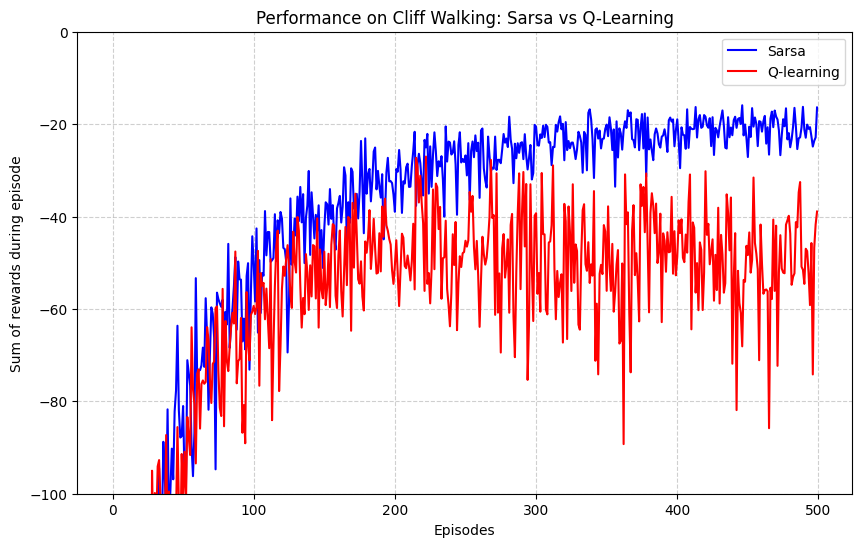

In [5]:
# --- Running the Experiment ---
EPISODES = 500
RUNS = 50

q_rewards = np.zeros(EPISODES)
sarsa_rewards = np.zeros(EPISODES)

final_q_table_qlearning = None
final_q_table_sarsa = None

print(f"Starting experiment: Averaging over {RUNS} runs to smooth the data...")

for i in range(RUNS):
    print(f"\rProgress: Computing run {i + 1} of {RUNS}...", end="")

    q_ep_rewards, final_q_table_qlearning = run_q_learning(EPISODES)
    sarsa_ep_rewards, final_q_table_sarsa = run_sarsa(EPISODES)

    # Adding the rewards to our running total
    q_rewards += q_ep_rewards
    sarsa_rewards += sarsa_ep_rewards

print("\nCalculations complete! Generating policy grids and graph...")

# Average the rewards
q_rewards /= RUNS
sarsa_rewards /= RUNS

# Print the visual grids to the console
print_policy(final_q_table_qlearning, "Q-Learning (Off-Policy)")
print_policy(final_q_table_sarsa, "Sarsa (On-Policy)")

# --- Calculate and Print Quantitative Metrics ---
print("\n--- Quantitative Performance Metrics ---")

# 1. Total Cumulative Reward (Sum of all 500 episodes)
print("Total Cumulative Reward (over 500 episodes):")
print(f"  Sarsa:      {np.sum(sarsa_rewards):.0f}")
print(f"  Q-Learning: {np.sum(q_rewards):.0f}")

# 2. Asymptotic Performance (Average of the final 100 episodes)
print("\nAsymptotic Performance (Average reward of last 100 episodes):")
print(f"  Sarsa:      {np.mean(sarsa_rewards[-100:]):.2f}")
print(f"  Q-Learning: {np.mean(q_rewards[-100:]):.2f}")
print("----------------------------------------\n")

# --- 5. Plotting the Results ---
plt.figure(figsize=(10, 6))
plt.plot(sarsa_rewards, label='Sarsa', color='blue', linewidth=1.5)
plt.plot(q_rewards, label='Q-learning', color='red', linewidth=1.5)
plt.xlabel('Episodes')
plt.ylabel('Sum of rewards during episode')
plt.title('Performance on Cliff Walking: Sarsa vs Q-Learning')
plt.ylim(-100, 0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Reflection on Experimental Results: Sarsa vs Q-Learning

The console output and performance graph illustrate the fundamental difference between on-policy and off-policy control methods.

---

## 1. Analysis of the Learned Policies (Arrow Grids)

### >> Q-Learning <<

```
--- Final Learned Policy: Q-Learning (Off-Policy) ---
 ←  ↑  →  →  →  →  →  ↓  →  ←  ↓  ↓
 →  →  →  ↓  →  →  →  ↓  ↓  ↓  ↓  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 S  C  C  C  C  C  C  C  C  C  C  G
----------------------------------------
```

In the Q-Learning grid, the arrows in the row immediately above the cliff (`C`) primarily point to the right (`→`). This indicates that the algorithm has learned the shortest path to the goal.

This risk-taking behaviour can be observed in Step 2(c) of the pseudocode, specifically in the use of the term `max_a Q(S', a)`. During the update, Q-Learning assumes that the agent will take the optimal next action, thereby ignoring the effects of the epsilon-greedy exploration strategy.

Even when the agent selects random exploratory actions and falls off the cliff (incurring the −100 penalty), this risk is not incorporated into the update target. The algorithm continues to update toward the maximum estimated future value, independent of the behaviour actually followed.

As a result, Q-Learning consistently optimises for the theoretically shortest path. While this leads to convergence toward the optimal greedy policy, it produces significantly lower cumulative reward during the training phase due to repeated exploratory penalties.

### >> Sarsa <<

```
--- Final Learned Policy: Sarsa (On-Policy) ---
 ↓  →  ←  →  →  →  →  →  →  →  ↓  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ←  ↑  →  →  ↑  →  ↑  ↑  →  ↓
 S  C  C  C  C  C  C  C  C  C  C  G
----------------------------------------
```

The Sarsa grid shows arrows pointing upward (`↑`) in states near the start and the cliff. This directs the agent to move to a safer row before proceeding toward the goal.

This risk-averse behaviour can be observed in Step 3(c) of the pseudocode, specifically in the use of the term `Q(S', A')`. During the update, Sarsa evaluates the next state based on the actual action selected under the current policy, thereby incorporating the effects of the epsilon-greedy exploration strategy.

Because exploratory actions are directly reflected in the update target, the algorithm explicitly accounts for the risk of falling off the cliff. When a random exploratory action results in a −100 penalty, this outcome is immediately integrated into the value update, ensuring that the learning process remains aligned with the behaviour being executed.

As a consequence, Sarsa converges toward a safer, though longer, route to the goal. Although this prevents it from learning the mathematically shortest path, it yields a higher cumulative reward during training by reducing exposure to severe penalties associated with the cliff.

---

## 2. Evaluation of the Performance Graph

### Online Performance

The performance graph shows that Sarsa consistently achieves a higher (less negative) cumulative reward during training, stabilising around approximately −20 as episodes increase.

### Effect of Exploration

Q-Learning exhibits more negative and more variable returns, frequently fluctuating between approximately −40 and −80. Although it learns the optimal shortest path, its epsilon-greedy exploration leads to repeated falls from the cliff, incurring large penalties.

Sarsa’s longer path results in slightly more step penalties (−1 per step), but by avoiding the −100 cliff penalty, it achieves better overall performance during training.

---

## 3. Quantitive Evaluation of the Performance

```
--- Quantitative Performance Metrics ---
Total Cumulative Reward (over 500 episodes):
  Sarsa:      -23640
  Q-Learning: -33131

Asymptotic Performance (Average reward of last 100 episodes):
  Sarsa:      -21.62
  Q-Learning: -48.70
```
# Quantitative Evaluation of Algorithm Performance

The results reflect the theoretical differences between the two algorithms. Over 500 training episodes, Sarsa achieved a total cumulative reward of −23,640, while Q-Learning accumulated −33,131. The lower total reward for Q-Learning is due to repeated cliff penalties (−100) caused by epsilon-greedy exploration during learning.

This difference is also visible in the final 100 episodes. Sarsa achieved an average reward of −21.62 per episode, which is consistent with the −1 step penalties along its longer but safer path.

Q-Learning averaged −48.70 per episode over the same period. Although it learned the shortest path, continued exploration resulted in occasional cliff penalties, lowering its average return.

Overall, Q-Learning converges to the optimal greedy policy, but Sarsa achieves higher reward during training because it accounts for exploration in its updates.

---

## Conclusion

The experiment demonstrates an important trade-off in reinforcement learning:

- Q-Learning converges toward the optimal greedy policy but performs poorly during training due to exploration.
- Sarsa learns a safer policy that reflects its exploratory behaviour, resulting in improved performance during the learning process.

TASK 2 - IMPLEMENTING MOUNTAIN CAR

Using the Gymasium environment - formerly OpenAI Gym; Implement a  DQN for a classic control problem such as the **Mountain Car** or Pendulum.

### Task 2: Implementing a Deep Q-Network (DQN) for Acrobot-v1

**My Understanding:** Traditional Q-Learning works well for simple grids (like Task 1), but fails when there are infinite, continuous states. To solve the Acrobot-v1 problem, we must upgrade from a basic Q-table to a Neural Network that can predict the best actions for any situation.



**The Environment (Acrobot-v1):**
* **Layout:** A two-link pendulum where only the middle joint is motorised. The agent receives 6 continuous data points (joint angles and movement speeds).
* **Actions:** 3 discrete choices: push left (-1), do nothing (0), or push right (+1).
* **Objective:** Swing the bottom link up to the target height in the fewest steps possible. Each step gives a penalty of -1, with a hard limit of 500 steps.



**The Solution:** I implemented a Standard Deep Q-Network (DQN). This uses the exact same underlying maths as the Q-Learning in Task 1, but introduces two vital upgrades: a Neural Network to estimate future rewards, and an "Experience Replay Buffer" (a memory bank) to learn from past actions and stabilise the training process.

#### Standard DQN Pseudocode (Pythonic Structure)

```
# Initialise experience replay buffer D
# Initialise Neural Network Q with random weights
    
for episode in range(episodes):
    # 1. Initialise starting state S
    state = env.reset()
        
    # 2. Step through the episode (up to 500 max steps)
    for step in range(500):
            
        # a. Select action using an epsilon-greedy policy
        if random_chance < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = argmax(Q_Network(state))  # Exploit
                
        # b. Take action, observe reward and next state
        next_state, reward, done = env.step(action)
            
        # c. Store the experience in the replay buffer
        replay_buffer.append((state, action, reward, next_state, done))
            
        # d. Sample a random mini-batch of past experiences
        batch = sample(replay_buffer)
            
        # e. Calculate the Bellman target
        # Target = R + gamma * max_a Q(S', a; theta)
        target = reward + discount_factor * max(Q_Network(next_state))
               
        # f. Perform gradient descent on the Mean Squared Error (MSE)
        loss = MSE(target, Q_Network(state, action))
        optimizer.update_weights(loss)
            
        # g. Update state
        state = next_state
               
        if done:
            break # Stop if terminal state is reached

Starting standard DQN training on Acrobot-v1...
Episode: 400/400, Steps: 89, Epsilon: 0.010, Reward: -88.0
Training complete! Best score: -63.0


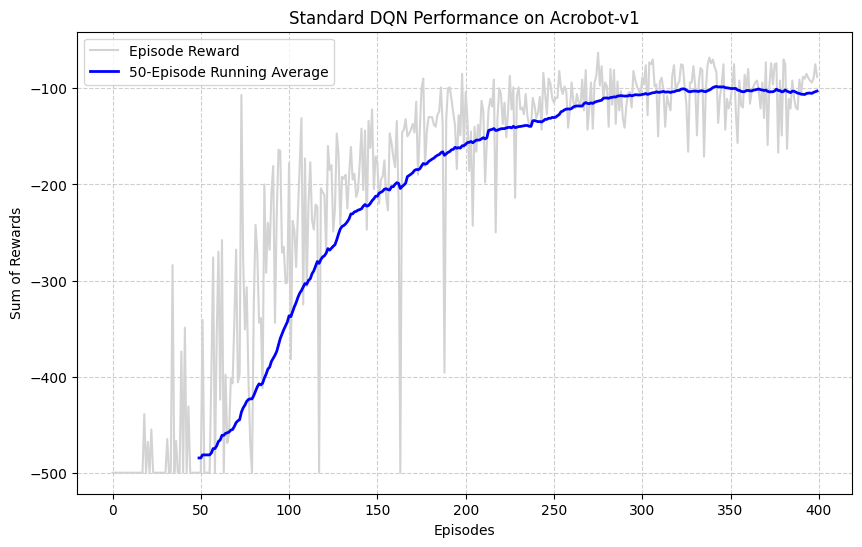

In [6]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

# --- 1. Environment and Neural Network Setup ---
env = gym.make("Acrobot-v1")
input_shape = [6] # Acrobot has 6 observations
n_outputs = 3     # Acrobot has 3 actions (-1, 0, +1 torque)

# A single, simple Neural Network (No Target Network!)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(n_outputs)
])

# --- 2. Hyperparameters and Replay Buffer ---
batch_size = 32
discount_factor = 0.99
optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

replay_buffer = deque(maxlen=20000)

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    states, actions, rewards, next_states, dones, truncateds = [
        np.array([experience[field_index] for experience in batch])
        for field_index in range(6)
    ]
    return states, actions, rewards, next_states, dones, truncateds

def play_one_step(env, state, epsilon):
    if np.random.rand() < epsilon:
        action = env.action_space.sample()
    else:
        Q_values = model(state[np.newaxis])
        action = np.argmax(Q_values[0])

    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

# --- 3. Training Step (Standard DQN) ---
@tf.function
def training_step(states, actions, rewards, next_states, dones, truncateds):
    # Just like tabular Q-Learning, we ask the model for the next states' Q-values...
    next_Q_values = model(next_states, training=False)

    # ...and simply take the maximum value (BUG 1 FIXED: .min changed to .max)
    max_next_Q_values = tf.reduce_max(next_Q_values, axis=1)

    runs = 1.0 - tf.cast(dones | truncateds, tf.float32)
    rewards = tf.cast(rewards, tf.float32)

    # The standard Bellman equation
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = tf.reshape(target_Q_values, [-1, 1])
    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states, training=True)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

# --- 4. Main Training Loop ---
episodes = 400
rewards_history = []
best_score = -500

print("Starting standard DQN training on Acrobot-v1...")

for episode in range(episodes):
    state, info = env.reset()
    episode_reward = 0

    # BUG 2 FIXED: Epsilon decays over time
    epsilon = max(1 - episode / (episodes * 0.8), 0.01)

    for step in range(500):
        state, reward, done, truncated, info = play_one_step(env, state, epsilon)
        episode_reward += reward

        # BUG 3 FIXED: Train every step, not just at the end of the episode
        if len(replay_buffer) > batch_size:
            experiences = sample_experiences(batch_size)
            training_step(*experiences)

        if done or truncated:
            break

    rewards_history.append(episode_reward)

    if episode_reward >= best_score:
        best_weights = model.get_weights()
        best_score = episode_reward

    print(f"\rEpisode: {episode + 1}/{episodes}, Steps: {step + 1}, Epsilon: {epsilon:.3f}, Reward: {episode_reward}", end="")

model.set_weights(best_weights)
print("\nTraining complete! Best score:", best_score)

# --- 5. Plotting ---
running_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')

plt.figure(figsize=(10, 6))
plt.plot(rewards_history, label='Episode Reward', color='lightgray')
plt.plot(range(49, episodes), running_avg, label='50-Episode Running Average', color='blue', linewidth=2)
plt.xlabel('Episodes')
plt.ylabel('Sum of Rewards')
plt.title('Standard DQN Performance on Acrobot-v1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

env.close()

In [9]:
import warnings
# Silence the moviepy string warning (SyntaxWarning) caused by Python 3.12
#warnings.filterwarnings("ignore", category=SyntaxWarning)
# Silence the Gymnasium overwrite warning for cleaner notebook output
#warnings.filterwarnings("ignore", category=UserWarning, module="gymnasium")

import gymnasium as gym
import numpy as np
import glob
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

env = gym.make("Acrobot-v1", render_mode="rgb_array") # 1. Create the environment
env = gym.wrappers.RecordVideo(env, video_folder='./video', disable_logger=True) # 2. Wrap the environment

# 3. Run exactly one episode using the fully trained online network
state, info = env.reset()
done = False
truncated = False

while not (done or truncated):
    Q_values = model(state[np.newaxis])
    action = np.argmax(Q_values[0])

    state, reward, done, truncated, info = env.step(action)

env.close() # Close the environment to finalise the MP4 file

video_files = glob.glob('./video/*.mp4')
video_path = video_files[-1]
video_b64 = base64.b64encode(open(video_path, 'rb').read()).decode('ascii')

# Generate the HTML to display the video player inline
display_html = f'''
<video width="600" controls autoplay loop>
    <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
</video>'''

print("Video rendered")
ipythondisplay.display(HTML(display_html))


Video rendered
